In [25]:
from google.colab import files
#load dataset
uploaded = files.upload()

Saving diabetes.csv to diabetes (1).csv


# Part 1: Data Loading and Exploration

In [26]:
import pandas as pd
df = pd.read_csv("diabetes.csv")

#display the first five rows
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [27]:
#count how many zero values exist in each column
(df == 0).sum()

,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,500


In [28]:
#generate statistical summary
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Part 2: Data Cleaning and Normalization

In [29]:
#create a copy of the dataset
df_new = df.copy()

#columns where 0 is an missing value
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

#replace zeros with the median of each column
for col in cols:
  median = df_new[col].median()
  df_new[col] = df_new[col].replace(0,median)

#create a copy of the copy
df_norma = df_new.copy()

#normalize all columns except the "Outcome" column
for col in df_norma.columns:
  if(col!='Outcome'):
    df_norma[col] = (df_norma[col]-df_norma[col].min())/(df_norma[col].max()-df_norma[col].min())

# Part 3: Data Visualization

Text(0, 0.5, 'Frequency')

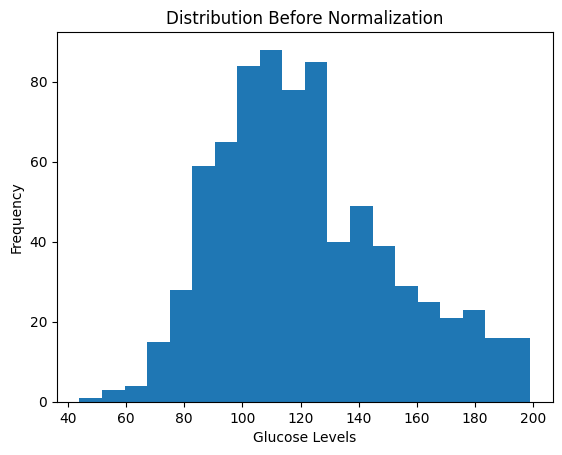

In [30]:
import matplotlib.pyplot as plt

#plot histogram of glucose values before normalization
plt.hist(df_new['Glucose'],bins=20)
plt.title('Distribution Before Normalization')
plt.xlabel('Glucose Levels')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

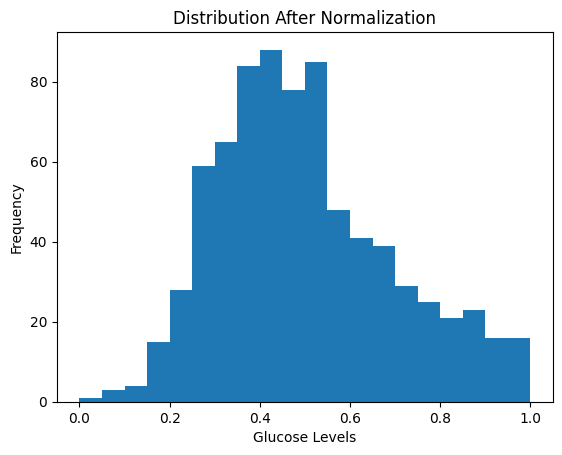

In [31]:
#plot histogram of glucose values after normalization
plt.hist(df_norma['Glucose'],bins=20)
plt.title('Distribution After Normalization')
plt.xlabel('Glucose Levels')
plt.ylabel('Frequency')

# Part 4: Answer the following questions

**1. What impact do missing values have on data analysis?**

Missing values can reduce the accuracy of analysis and lead to biased results if not handled properly. They may cause errors in algorithms that require complete data and can distort statistical measures like the mean or variance.

**2. How can we detect and handle outliers in biomedical datasets?**

Outliers can be detected using statistical methods, as well as visual tools like boxplots and histograms. They can be handled by removing them, capping extreme values, or using robust methods that are less sensitive to them.

**3. What are some common causes of missing or incorrect data in biomedical studies?**

Missing or incorrect data can result from human errors, faulty equipment, skipped patient visits, data entry mistakes, or inconsistencies in measurement procedures across studies.

**4. How does normalizing data improve the performance of Machine Learning models?**

Normalizing data puts all features on a similar scale, which helps models learn more effectively. It prevents variables with larger ranges from dominating and improves performance, especially in distance-based algorithms.

**5. Why is visualizing data an important step before applying Machine Learning models?**

Visualization helps identify patterns, trends, and anomalies in the data. It allows for a better understanding of distributions and potential issues before building models.

**6. Why is preprocessing critical when working with medical datasets?**

Preprocessing ensures the data is clean, consistent, and usable for analysis. In medical datasets, this step is crucial to avoid errors and ensure reliable and meaningful results.

**7. What ethical concerns should be considered when handling patient data?**

Ethical concerns include protecting patient privacy, securing sensitive information, obtaining proper consent, and avoiding bias or misuse of data in analysis and decision-making.